---
title: xarray EOPF backend: Sentinel-3
Subtitle: Access Sentinel-3 in Analysis Mode
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-03-27
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-3", "xarray-eopf", "land"]
releaseDate: 2026-03-27
datePublished: 2026-03-27
dateModified: 2026-03-27
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XEOPF_SEN3_ANALYSIS)
2. [Main Features of the Analysis Mode for Sentinel-3](#Main_Features_XEOPF_SEN3_ANALYSIS)
3. [Import modules](#Import_XEOPF_SEN3_ANALYSIS)
4. [Open a Sentinel-3 OLCI L1 EFR](#Open_OLCI_L1_EFR_XEOPF_SEN3_ANALYSIS)
5. [Open a Sentinel-3 OLCI L1 ERR](#Open_OLCI_L1_ERR_XEOPF_SEN3_ANALYSIS)
6. [Open a Sentinel-3 SLSTR Level-2 LST](#Open_SLSTR_L2_LST_XEOPF_SEN3_ANALYSIS)
7. [Open Sentinel-3 SLSTR Level-1B RBT](#Open_SLSTR_L1_RBT_XEOPF_SEN3_ANALYSIS)
8. [Conclusion](#Conclusion_XEOPF_SEN3_ANALYSIS)

(Introduction_XEOPF_SEN3_ANALYSIS)=
## Introduction

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-3** EOPF Zarr products in **analysis mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage. 

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).  
For an example of the native mode, see the [Sentinel-3 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_3_native/).


- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

:::{hint} Overview
**Questions**
- How can I use the xarray-eopf backend for Sentinel-3 in analysis mode?
- What main features does the xarray-eopf backend provide for Sentinel-3 in analysis mode?

**Objectives**
- Learn how to open Sentinel-3 EOPF Zarr products using `xarray-eopf`.
- Understand the key features and capabilities of the `xarray-eopf` backend in analysis mode for Sentinel-3.
:::

(Main_Features_XEOPF_SEN3_ANALYSIS)=
## Main Features of the Analysis Mode for Sentinel-3

Sentinel-3 products are provided on their **native grid**, where each pixel is defined by a latitude/longitude pair, forming a **2D curvilinear (irregular) grid**.

The analysis mode applies the [rectification algorithm in xcube-resampling](https://xcube-dev.github.io/xcube-resampling/guide/#3-rectification) to transform this irregular grid into a **regular (rectilinear) grid** with 1D latitude and longitude coordinates.

For **SLSTR** products, an additional terrain correction is applied during this process. This is necessary because the original geolocation accounts for Earth curvature, but not for terrain-induced variability due to topography. See the [SLSTR product description](https://sentiwiki.copernicus.eu/web/slstr-products) for details.

For **OLCI** products, no additional terrain correction is required, as it is already included in the Level-1 data. See the [OLCI Level-1 product description](https://sentiwiki.copernicus.eu/web/olci-products#OLCIProducts-L1BProducts-ObservationModeS3-OLCI-Products-L1B-OM) for details.

### Key Properties of Sentinel-3 Analysis Mode

- **Default mode** for the `"eopf-zarr"` backend  
- **Rectification**: converts the 2D curvilinear grid into a rectilinear grid  
- **Spatial subsetting** via the `bbox` argument  
- **Reprojection** to different CRS via the `crs` argument (default: WGS84, EPSG:4326)  
- **Flexible variable selection** using names or regular expressions  

For full details on available parameters, see the [Analysis Mode documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#analysis-mode) and, specifically for Sentinel-3, the [Sentinel-3 Analysis Mode guide](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-3).

---

(Import_XEOPF_SEN3_ANALYSIS)=
## Import Modules

The `xarray-eopf` backend is implemented as a plugin for `xarray`. Once installed, it registers automatically and requires no additional import. You can simply import `xarray` as usual:

In [1]:
import datetime

import matplotlib.pyplot as plt
import pyproj
import pystac_client
import xarray as xr

---

(Open_OLCI_L1_EFR_XEOPF_SEN3_ANALYSIS)=
## Open a Sentinel-3 OLCI L1 EFR

We begin with an example that accesses a Sentinel-3 OLCI L1 EFR product in **analysis mode**. 

### Find a Sentinel-3 OLCI L1 EFR Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l1-efr) to search for a Sentinel-3 OLCI Level-1 EFR tile.

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-olci-l1-efr"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=5)), None],
    ).items()
)
items

[<Item id=S3B_OL_1_EFR____20260330T091943_20260330T092243_20260330T112427_0179_118_207_2160_ESA_O_NR_004>,
 <Item id=S3B_OL_1_EFR____20260329T094553_20260329T094853_20260329T114455_0179_118_193_2160_ESA_O_NR_004>,
 <Item id=S3B_OL_1_EFR____20260329T094553_20260329T094853_20260330T110844_0179_118_193_2160_ESA_O_NT_004>,
 <Item id=S3B_OL_1_EFR____20260328T101204_20260328T101504_20260328T121637_0179_118_179_2160_ESA_O_NR_004>,
 <Item id=S3B_OL_1_EFR____20260328T101204_20260328T101504_20260329T100706_0180_118_179_2160_ESA_O_NT_004>,
 <Item id=S3A_OL_1_EFR____20260327T093557_20260327T093857_20260328T103721_0179_137_307_2160_PS1_O_NT_004>,
 <Item id=S3A_OL_1_EFR____20260327T093557_20260327T093857_20260327T113653_0180_137_307_2160_PS1_O_NR_004>,
 <Item id=S3A_OL_1_EFR____20260326T100207_20260326T100507_20260327T110434_0180_137_293_2160_PS1_O_NT_004>,
 <Item id=S3A_OL_1_EFR____20260326T100207_20260326T100507_20260326T120302_0179_137_293_2160_PS1_O_NR_004>,
 <Item id=S3B_OL_1_EFR____20260326T09

In [3]:
item = items[0]
item

<Item id=S3B_OL_1_EFR____20260330T091943_20260330T092243_20260330T112427_0179_118_207_2160_ESA_O_NR_004>

### Open Sentinel-3 OLCI L1 EFR with default parameters

We can now open the Sentinel-3 product in **analysis mode** using the `xr.open_dataset` method. Since this is the default, the `op_mode` parameter does not need to be specified.  

The following cell returns a **lazy dataset**, with all bands recifified to a regular grid. If no `resolution` is given, the spatial resolution is estimated from the 2D latitude and longitude grids.

In [4]:
ds = xr.open_dataset(item.assets["product"].href, engine="eopf-zarr", chunks={})
ds

<xarray.Dataset> Size: 4GB
Dimensions:        (lon: 5158, lat: 4792)
Coordinates:
  * lon            (lon) float64 41kB 5.501 5.505 5.509 ... 25.5 25.5 25.51
  * lat            (lat) float64 38kB 52.46 52.45 52.45 ... 39.55 39.55 39.54
    spatial_ref    int64 8B ...
Data variables: (12/21)
    oa01_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa02_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa03_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa04_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa05_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa06_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    ...             ...
    oa16_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa17_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa18_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa19_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa20_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa21_radiance  (lat, lon) float64 198MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (8)

As an example, we plot the **red band** (`oa08_radiance`), which triggers data loading, rectification, and visualization of the rectified result.

> **Note:** To speed up rendering of large datasets in Matplotlib, we plot the data at a lower resolution (every 4th pixel).

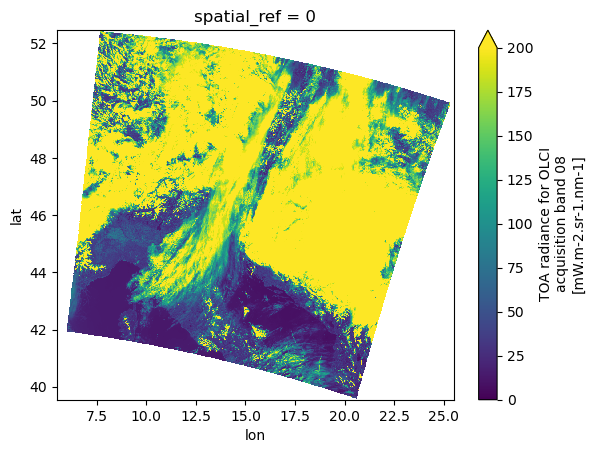

In [5]:
ds.oa08_radiance[::4, ::4].plot(vmin=0.0, vmax=200.0)

### Spatial Resampling, Subsetting and Reprojection

We can also change the resolution and display only a subset of the data by specifying the `bbox` argument, as shown below.

In [6]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    resolution=0.01,
    bbox=[5, 40, 15, 48],
    chunks={},
)
ds

<xarray.Dataset> Size: 134MB
Dimensions:        (lon: 1000, lat: 800)
Coordinates:
  * lon            (lon) float64 8kB 5.005 5.015 5.025 ... 14.97 14.98 14.99
  * lat            (lat) float64 6kB 47.99 47.98 47.97 ... 40.03 40.02 40.01
    spatial_ref    int64 8B ...
Data variables: (12/21)
    oa01_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa02_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa03_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa04_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa05_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa06_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    ...             ...
    oa16_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa17_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa18_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa19_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa20_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
    oa21_radiance  (lat, lon) float64 6MB dask.array<chunksize=(800, 1000), meta=np.ndarray>
Attributes: (8)

As an example, we plot again the red band (`oa08_radiance`).

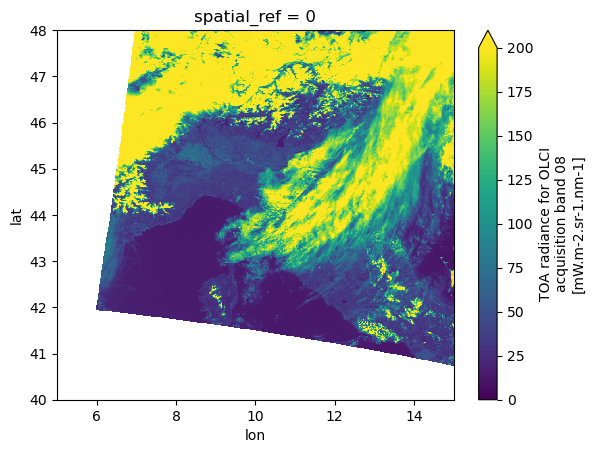

In [7]:
ds.oa08_radiance.plot(vmin=0.0, vmax=200.0)

We can request the same area in **LAEA CRS** by specifying `crs="EPSG:3035"`. Note that both the `resolution` and `bbox` must be provided in the CRS units.

In [8]:
bbox = [5, 40, 15, 48]
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
bbox_crs = transformer.transform_bounds(*bbox)
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    crs="EPSG:3035",
    resolution=1000,
    bbox=bbox_crs,
    chunks={},
)
ds

<xarray.Dataset> Size: 130MB
Dimensions:        (x: 858, y: 900)
Coordinates:
  * x              (x) float64 7kB 3.893e+06 3.894e+06 ... 4.749e+06 4.75e+06
  * y              (y) float64 7kB 2.778e+06 2.777e+06 ... 1.88e+06 1.879e+06
    spatial_ref    int64 8B ...
Data variables: (12/21)
    oa01_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa02_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa03_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa04_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa05_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa06_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    ...             ...
    oa16_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa17_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa18_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa19_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa20_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
    oa21_radiance  (y, x) float64 6MB dask.array<chunksize=(900, 858), meta=np.ndarray>
Attributes: (8)

We plot the red band (`oa08_radiance`).

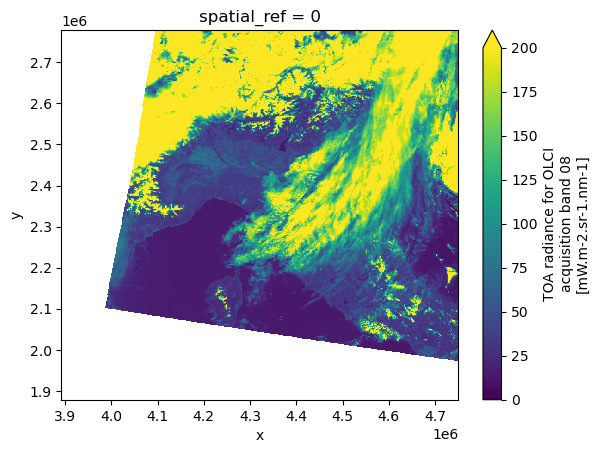

In [9]:
ds.oa08_radiance.plot(vmin=0.0, vmax=200.0)

---

(Open_OLCI_L1_ERR_XEOPF_SEN3_ANALYSIS)=
## Open a Sentinel-3 OLCI L1 ERR

We now access a Sentinel-3 OLCI L1 ERR product in **analysis mode**. The data access methods shown above apply equally to Sentinel-3 OLCI L1 EFR.

### Find a Sentinel-3 OLCI L1 ERR Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l1-err) to search for available Sentinel-3 OLCI L1 ERR tiles.

In [10]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-olci-l1-err"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=5)), None],
    ).items()
)
items

[<Item id=S3B_OL_1_ERR____20260330T090925_20260330T095330_20260330T113721_2645_118_207______ESA_O_NR_004>,
 <Item id=S3B_OL_1_ERR____20260329T093543_20260329T101948_20260330T105135_2645_118_193______ESA_O_NT_004>,
 <Item id=S3B_OL_1_ERR____20260329T093543_20260329T101948_20260329T120344_2645_118_193______ESA_O_NR_004>,
 <Item id=S3B_OL_1_ERR____20260328T100201_20260328T104605_20260329T095351_2644_118_179______ESA_O_NT_004>,
 <Item id=S3B_OL_1_ERR____20260328T100201_20260328T104605_20260328T122605_2644_118_179______ESA_O_NR_004>,
 <Item id=S3A_OL_1_ERR____20260327T092601_20260327T101004_20260328T103618_2643_137_307______PS1_O_NT_004>,
 <Item id=S3A_OL_1_ERR____20260327T092601_20260327T101004_20260327T113524_2643_137_307______PS1_O_NR_004>,
 <Item id=S3A_OL_1_ERR____20260326T095219_20260326T103622_20260327T110333_2643_137_293______PS1_O_NT_004>,
 <Item id=S3A_OL_1_ERR____20260326T095219_20260326T103622_20260326T120200_2643_137_293______PS1_O_NR_004>,
 <Item id=S3B_OL_1_ERR____20260326T09

In [11]:
item = items[0]

### Open Sentinel-3 OLCI L1 ERR with Default Parameters

We can now open the Sentinel-3 product in **analysis mode** using the `xr.open_dataset` method, as before.  

If no spatial subsetting is applied via the `bbox` argument, the full dataset (typically covering half an orbit) is rectified to a regular grid in the WGS84 coordinate reference system.

In [12]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    resolution=0.01,
    bbox=[-0, 20, 40, 60],
    chunks={},
)
ds

<xarray.Dataset> Size: 3GB
Dimensions:        (lon: 4000, lat: 4000)
Coordinates:
  * lon            (lon) float64 32kB 0.005 0.015 0.025 ... 39.97 39.98 39.99
  * lat            (lat) float64 32kB 59.99 59.98 59.97 ... 20.03 20.02 20.01
    spatial_ref    int64 8B ...
Data variables: (12/21)
    oa01_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa02_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa03_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa04_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa05_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa06_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    ...             ...
    oa16_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa17_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa18_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa19_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa20_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    oa21_radiance  (lat, lon) float64 128MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (8)

As an example, we plot the **red band** (`oa08_radiance`), which triggers data loading, rectification, and visualization of the rectified result.

> **Note:** To speed up rendering of large datasets in Matplotlib, we plot the data at a lower resolution (every 10th pixel).

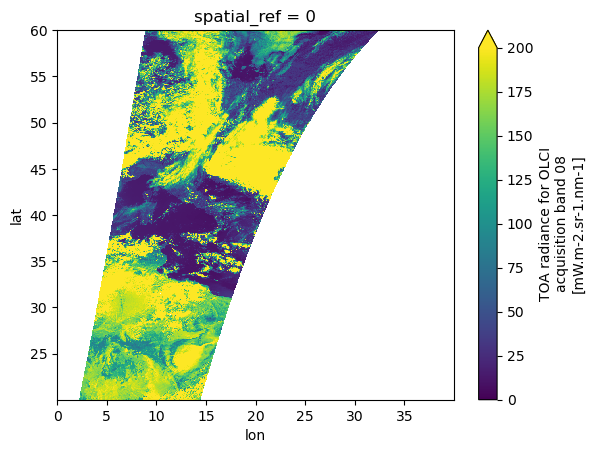

In [13]:
ds.oa08_radiance[::4, ::4].plot(vmin=0.0, vmax=200.0)

---

(Open_SLSTR_L2_LST_XEOPF_SEN3_ANALYSIS)=
## Open a Sentinel-3 SLSTR Level-2 LST

We now access a Sentinel-3 SLSTR Level-2 LST product in **analysis mode**. The data access methods shown above apply equally to Sentinel-3 SLSTR Level-2 LST.

### Find a Sentinel-3 SLSTR Level-2 LST Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l2-lst) to search for a Sentinel-3 SLSTR Level-2 LST tile.

In [14]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-slstr-l2-lst"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=5)), None],
    ).items()
)
items

[<Item id=S3B_SL_2_LST____20260330T091943_20260330T092243_20260330T113544_0179_118_207_2160_ESA_O_NR_004>,
 <Item id=S3A_SL_2_LST____20260329T214729_20260329T215029_20260330T003114_0179_137_343_0720_PS1_O_NR_004>,
 <Item id=S3B_SL_2_LST____20260329T210848_20260329T211148_20260329T235533_0179_118_200_0720_ESA_O_NR_004>,
 <Item id=S3A_SL_2_LST____20260329T102435_20260329T102735_20260329T125030_0179_137_336_2160_PS1_O_NR_004>,
 <Item id=S3B_SL_2_LST____20260329T094553_20260329T094853_20260329T121220_0179_118_193_2160_ESA_O_NR_004>,
 <Item id=S3B_SL_2_LST____20260328T213459_20260328T213759_20260329T001031_0179_118_186_0720_ESA_O_NR_004>,
 <Item id=S3B_SL_2_LST____20260328T213459_20260328T213759_20260330T051647_0179_118_186_0720_ESA_O_NT_004>,
 <Item id=S3A_SL_2_LST____20260328T203241_20260328T203541_20260328T231506_0179_137_328_0720_PS1_O_NR_004>,
 <Item id=S3A_SL_2_LST____20260328T203241_20260328T203541_20260330T081257_0179_137_328_0720_PS1_O_NT_004>,
 <Item id=S3B_SL_2_LST____20260328T10

In [15]:
item = items[0]

### Open Sentinel-3 SLSTR Level-2 LST with Default Parameters

We can now open the Sentinel-3 product in **analysis mode** using the `xr.open_dataset` method, as before.

In [16]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
)
ds

<xarray.Dataset> Size: 20MB
Dimensions:      (lon: 1668, lat: 1479)
Coordinates:
  * lon          (lon) float64 13kB 5.926 5.938 5.951 5.964 ... 27.38 27.39 27.4
  * lat          (lat) float64 12kB 52.43 52.42 52.42 ... 39.17 39.16 39.16
    spatial_ref  int64 8B ...
Data variables:
    lst          (lat, lon) float64 20MB dask.array<chunksize=(1479, 1668), meta=np.ndarray>
Attributes: (15)

As an example, we plot the **LST array**, which triggers data loading, rectification, and visualization of the rectified result.

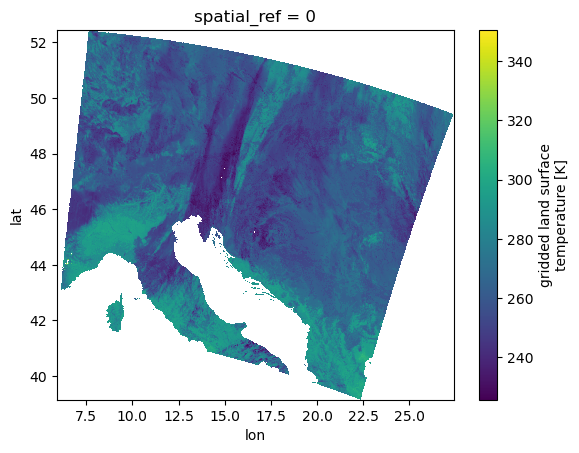

In [17]:
ds.lst.plot()

---

(Open_SLSTR_L1_RBT_XEOPF_SEN3_ANALYSIS)=
## Open Sentinel-3 SLSTR Level-1B RBT

We now access a Sentinel-3 SLSTR Level-1B RBT product in **analysis mode**. 

The SLSTR instrument provides observations from two viewing geometries: **nadir** and **oblique** (forward view). These are designed to improve atmospheric correction and enable more accurate surface measurements.

Accordingly, many variables in the RBT product are available in pairs:
- `*_an` → **nadir view** (e.g. `s1_radiance_an`)
- `*_ao` → **oblique view** (e.g. `s1_radiance_ao`)

### Find a Sentinel-3 SLSTR Level-1B RBT Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l1-rbt) to search for a Sentinel-3 SLSTR Level-1B RBT tile.

In [18]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-slstr-l1-rbt"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=6)), None],
    ).items()
)
items

[<Item id=S3B_SL_1_RBT____20260330T091943_20260330T092243_20260330T113200_0179_118_207_2160_ESA_O_NR_004>,
 <Item id=S3A_SL_1_RBT____20260329T214729_20260329T215029_20260330T002523_0179_137_343_0720_PS1_O_NR_004>,
 <Item id=S3B_SL_1_RBT____20260329T210848_20260329T211148_20260329T235156_0179_118_200_0720_ESA_O_NR_004>,
 <Item id=S3A_SL_1_RBT____20260329T102435_20260329T102735_20260329T124343_0179_137_336_2160_PS1_O_NR_004>,
 <Item id=S3B_SL_1_RBT____20260329T094553_20260329T094853_20260329T120822_0179_118_193_2160_ESA_O_NR_004>,
 <Item id=S3B_SL_1_RBT____20260328T213459_20260328T213759_20260329T000337_0179_118_186_0720_ESA_O_NR_004>,
 <Item id=S3B_SL_1_RBT____20260328T213459_20260328T213759_20260330T031418_0179_118_186_0720_ESA_O_NT_004>,
 <Item id=S3A_SL_1_RBT____20260328T203241_20260328T203541_20260328T230845_0179_137_328_0720_PS1_O_NR_004>,
 <Item id=S3A_SL_1_RBT____20260328T203241_20260328T203541_20260330T075507_0179_137_328_0720_PS1_O_NT_004>,
 <Item id=S3B_SL_1_RBT____20260328T10

In [19]:
item = items[-1]

### Open Sentinel-3 SLSTR Level-1B RBT with Default Parameters

We can now open the Sentinel-3 product in **analysis mode** using the `xr.open_dataset` method, as before.

In [20]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
)
ds

<xarray.Dataset> Size: 2GB
Dimensions:         (lon: 3366, lat: 2960)
Coordinates:
  * lon             (lon) float64 27kB 7.129 7.136 7.142 ... 28.8 28.8 28.81
  * lat             (lat) float64 24kB 52.45 52.45 52.44 ... 39.17 39.17 39.16
    spatial_ref     int64 8B ...
Data variables: (12/28)
    s1_radiance_an  (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s2_radiance_an  (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s3_radiance_an  (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s4_radiance_an  (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s5_radiance_an  (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s6_radiance_an  (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    ...              ...
    s8_bt_in        (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s9_bt_in        (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    f2_bt_io        (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s7_bt_io        (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s8_bt_io        (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    s9_bt_io        (lat, lon) float64 80MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (89)

As an example, we plot the nadir and oblique views of the S1 thermal channel side by side.

CPU times: user 25.9 s, sys: 6.41 s, total: 32.4 s
Wall time: 17.6 s


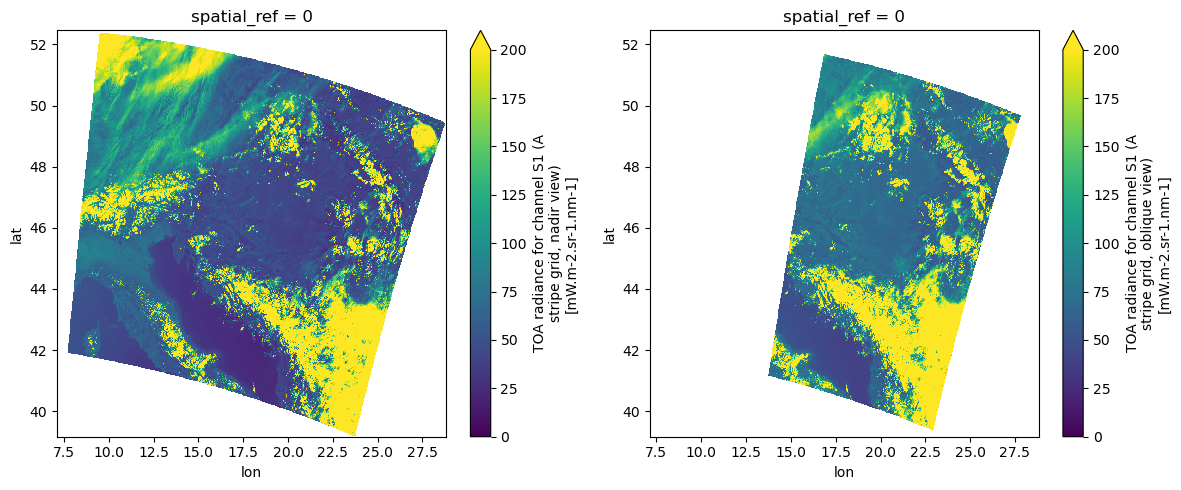

In [22]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.s1_radiance_an[::4, ::4].plot(ax=ax[0], vmin=0, vmax=200)
ds.s1_radiance_ao[::4, ::4].plot(ax=ax[1], vmin=0, vmax=200)
plt.tight_layout()

Other Sentinel-3 products can be accessed using the same approach and are therefore not shown here in detail.

---

## Conclusion

This notebook demonstrates how to access Sentinel-2 EOPF Zarr samples in **analysis mode** using the **xarray-eopf** plugin. The key takeaways are:

- **Analysis mode** is the default `op_mode`.
- In analysis mode, Sentinel-3 spectral bands are rectified to a rectilinear grid  
- Data can be accessed lazily at a **user-defined resolution, bounding box, and CRS**, enabling flexible resampling, subsetting, and reprojection.

> **Note:** This notebook only covers **analysis mode** for Sentinel-3. To learn more about **native mode**, see the [Sentinel-3 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_3_native/).

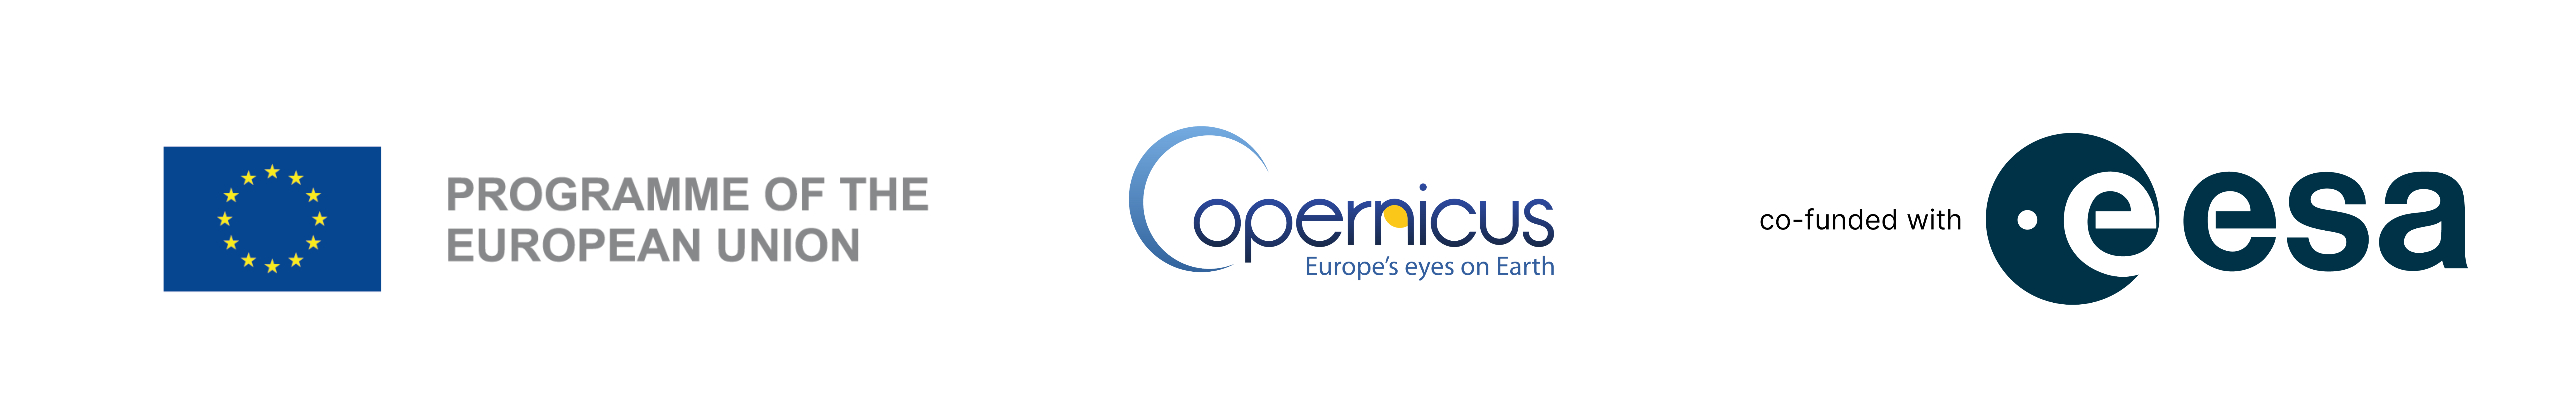